<a href="https://colab.research.google.com/github/galsencode12/Churn_Prediction_Project/blob/main/Churn_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Librairies de base
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
# Lien correct vers le dataset Telco Customer Churn
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.head()



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape


(7043, 21)

In [ ]:
# Afficher les informations générales du dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# ==========================================================
# Vérification des valeurs manquantes
# ==========================================================

df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# ==========================================================
# ÉTAPE 6 : Nettoyage de la colonne TotalCharges
# ==========================================================

# Convertir TotalCharges en numérique
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Vérifier les valeurs manquantes après conversion
df["TotalCharges"].isnull().sum()


np.int64(11)

In [ ]:
# Supprimer les lignes contenant des valeurs manquantes
df = df.dropna()

# Vérifier la nouvelle taille du dataset
df.shape


(7032, 21)

In [ ]:
# ==========================================================
# ÉTAPE 7 : Encodage de la variable cible
# ==========================================================

# Transformer Yes/No en 1/0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Vérifier la transformation
df["Churn"].value_counts()


,count
Churn,
0,5163
1,1869


In [ ]:
# ==========================================================
# ÉTAPE 8 : Séparation des features et de la target
# ==========================================================

# Supprimer customerID (identifiant inutile)
df = df.drop("customerID", axis=1)

# Séparer X (features) et y (target)
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Vérification des dimensions
X.shape, y.shape


((7032, 19), (7032,))

In [ ]:
# ==========================================================
# Vérifier les types de variables
# ==========================================================

X.dtypes


,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [ ]:
# ==========================================================
# ÉTAPE 9 : Encodage des variables catégorielles
# ==========================================================

# Transformer toutes les variables catégorielles en variables numériques
X = pd.get_dummies(X, drop_first=True)

# Vérifier la nouvelle dimension
X.shape


(7032, 30)

In [ ]:
# ==========================================================
# ÉTAPE 10 : Séparation Train / Test
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # conserve la proportion churn/non-churn
)

# Vérification des dimensions
X_train.shape, X_test.shape


((5625, 30), (1407, 30))

CLASSIFICATION REPORT COMPLET
               precision    recall  f1-score   support

Non-Churn (0)       0.83      0.89      0.86      1033
    Churn (1)       0.62      0.49      0.55       374

     accuracy                           0.79      1407
    macro avg       0.73      0.69      0.70      1407
 weighted avg       0.77      0.79      0.78      1407


MATRICE DE CONFUSION:
[[920 113]
 [189 185]]

Détail de la matrice de confusion:
Vrais Négatifs (TN): 920 - Clients correctement prédits comme non-churn
Faux Positifs (FP): 113 - Clients incorrectement prédits comme churn
Faux Négatifs (FN): 189 - Clients incorrectement prédits comme non-churn
Vrais Positifs (TP): 185 - Clients correctement prédits comme churn


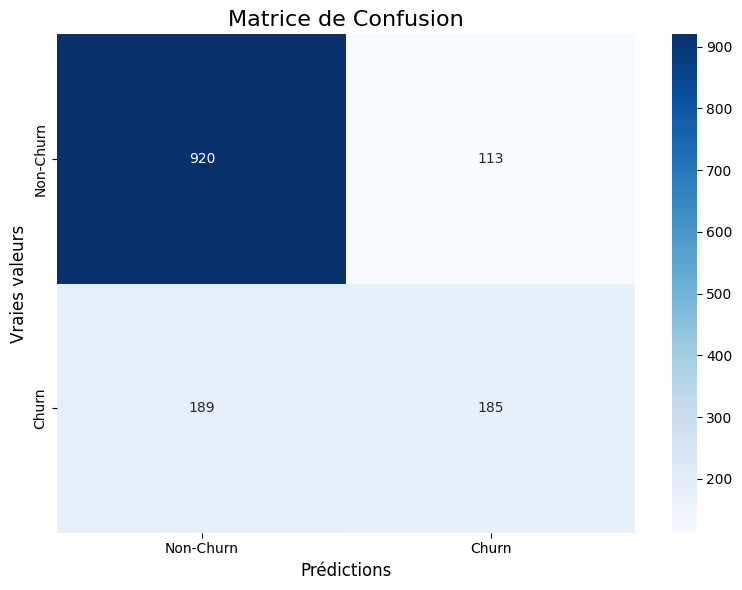


MÉTRIQUES DÉTAILLÉES
Accuracy: 0.7854

Pour la classe Non-Churn (0):
  Précision: 0.8296
  Rappel: 0.8906
  F1-score: 0.8590

Pour la classe Churn (1):
  Précision: 0.6208
  Rappel: 0.4947
  F1-score: 0.5506


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

#  Charger les données
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

#  Préparation des données
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

#  Encoder les variables catégorielles
le = LabelEncoder()
for col in df.select_dtypes(['object']).columns:
    df[col] = le.fit_transform(df[col])

#  Séparer features et target
X = df.drop('Churn', axis=1)
y = df['Churn']

#  Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Standardiser
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  Entraîner le modèle
model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(X_train_scaled, y_train)

#  Prédire
y_pred = model.predict(X_test_scaled)

#  AFFICHER LE CLASSIFICATION REPORT COMPLET
print("=" * 50)
print("CLASSIFICATION REPORT COMPLET")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Non-Churn (0)', 'Churn (1)']))
print("=" * 50)

#  AFFICHER LA MATRICE DE CONFUSION
print("\nMATRICE DE CONFUSION:")
print("=" * 50)
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("\nDétail de la matrice de confusion:")
print(f"Vrais Négatifs (TN): {cm[0,0]} - Clients correctement prédits comme non-churn")
print(f"Faux Positifs (FP): {cm[0,1]} - Clients incorrectement prédits comme churn")
print(f"Faux Négatifs (FN): {cm[1,0]} - Clients incorrectement prédits comme non-churn")
print(f"Vrais Positifs (TP): {cm[1,1]} - Clients correctement prédits comme churn")

# 1 VISUALISATION DE LA MATRICE DE CONFUSION
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Churn', 'Churn'],
            yticklabels=['Non-Churn', 'Churn'])
plt.title('Matrice de Confusion', fontsize=16)
plt.ylabel('Vraies valeurs', fontsize=12)
plt.xlabel('Prédictions', fontsize=12)
plt.tight_layout()
plt.show()

#  MÉTRIQUES DÉTAILLÉES
print("\n" + "=" * 50)
print("MÉTRIQUES DÉTAILLÉES")
print("=" * 50)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Précision, Rappel, F1-score manuellement
tn, fp, fn, tp = cm.ravel()

precision_churn = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_churn = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_churn = 2 * (precision_churn * recall_churn) / (precision_churn + recall_churn) if (precision_churn + recall_churn) > 0 else 0

precision_no_churn = tn / (tn + fn) if (tn + fn) > 0 else 0
recall_no_churn = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_no_churn = 2 * (precision_no_churn * recall_no_churn) / (precision_no_churn + recall_no_churn) if (precision_no_churn + recall_no_churn) > 0 else 0

print(f"\nPour la classe Non-Churn (0):")
print(f"  Précision: {precision_no_churn:.4f}")
print(f"  Rappel: {recall_no_churn:.4f}")
print(f"  F1-score: {f1_no_churn:.4f}")

print(f"\nPour la classe Churn (1):")
print(f"  Précision: {precision_churn:.4f}")
print(f"  Rappel: {recall_churn:.4f}")
print(f"  F1-score: {f1_churn:.4f}")

In [ ]:

# Logistic Regression avec gestion du déséquilibre


log_model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model_balanced.fit(X_train, y_train)

y_pred_balanced = log_model_balanced.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_balanced))

print("\nClassification Report :")
print(classification_report(y_test, y_pred_balanced))


Accuracy : 0.736318407960199

Classification Report :
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:

# ÉTAPE 13 : Random Forest


rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report :")
print(classification_report(y_test, y_pred_rf))


Accuracy : 0.783226723525231

Classification Report :
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.46      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



In [ ]:

# Importance des variables - Random Forest


importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(10)


,Feature,Importance
18,TotalCharges,0.170136
17,MonthlyCharges,0.162138
4,tenure,0.153342
14,Contract,0.111925
8,OnlineSecurity,0.057235
11,TechSupport,0.052256
16,PaymentMethod,0.048044
7,InternetService,0.030806
9,OnlineBackup,0.026376
0,gender,0.025712
